In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
import torchvision.models as models

from PIL import Image
import matplotlib.pyplot as plt

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

loader = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

def load_image(path):
    image = Image.open(path)
    image = loader(image).unsqueeze(0)
    return image.to(device, torch.float)

In [25]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

content_img, label = dataset[10]
content_img = content_img.unsqueeze(0).to(device)

100%|██████████| 170M/170M [00:13<00:00, 12.9MB/s]


In [36]:
style_img = load_image("/content/f15.jpg")

print(content_img.shape)

torch.Size([1, 3, 256, 256])


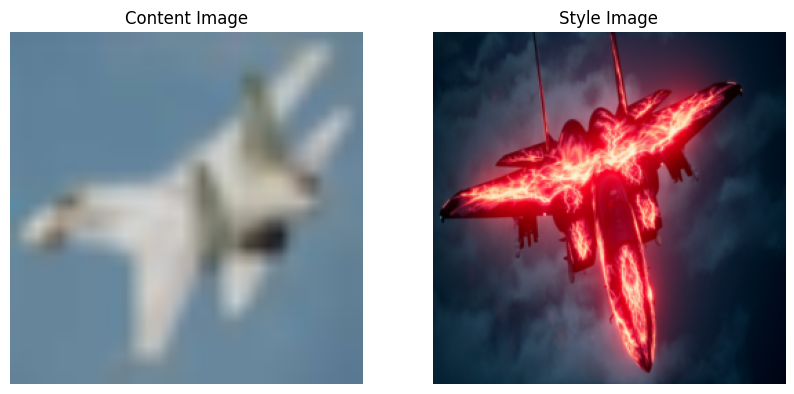

In [37]:
def imshow(tensor, title=None):

    image = tensor.cpu().clone()
    image = image.squeeze(0)
    image = transforms.ToPILImage()(image)

    plt.imshow(image)

    if title:
        plt.title(title)

    plt.axis("off")


plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
imshow(content_img, "Content Image")

plt.subplot(1,2,2)
imshow(style_img, "Style Image")

plt.show()

In [38]:
vgg = models.vgg19(pretrained=True).features.to(device).eval()

for param in vgg.parameters():
    param.requires_grad = False

In [39]:
content_layers = ['21']   # conv4_2
style_layers = ['0','5','10','19','28']

In [40]:
def get_features(image, model):

    features = {}
    x = image

    for name, layer in model._modules.items():

        x = layer(x)

        if name in content_layers:
            features["content"] = x

        if name in style_layers:
            features[name] = x

    return features

In [41]:
def gram_matrix(tensor):

    b,c,h,w = tensor.size()

    tensor = tensor.view(c, h*w)

    gram = torch.mm(tensor, tensor.t())

    return gram

In [42]:
content_features = get_features(content_img, vgg)
style_features = get_features(style_img, vgg)

style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}
content_weight = 1e4
style_weight = 1e2

In [43]:
target = content_img.clone().requires_grad_(True).to(device)

optimizer = optim.Adam([target], lr=0.003)

In [44]:
steps = 10000

for step in range(steps):

    target_features = get_features(target, vgg)

    # Content loss
    content_loss = torch.mean(
        (target_features["content"] - content_features["content"])**2
    )

    # Style loss
    style_loss = 0

    for layer in style_layers:

        target_feature = target_features[layer]
        target_gram = gram_matrix(target_feature)

        style_gram = style_grams[layer]

        _,c,h,w = target_feature.shape

        layer_loss = torch.mean((target_gram - style_gram)**2)

        style_loss += layer_loss / (c*h*w)

    total_loss = content_weight*content_loss + style_weight*style_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if step % 500 == 0:
        print("Step:",step," Loss:",total_loss.item())

Step: 0  Loss: 541.8606567382812
Step: 500  Loss: 410.4778747558594
Step: 1000  Loss: 361.8289794921875
Step: 1500  Loss: 328.5382080078125
Step: 2000  Loss: 332.08807373046875
Step: 2500  Loss: 301.55181884765625
Step: 3000  Loss: 296.6014099121094
Step: 3500  Loss: 283.0896911621094
Step: 4000  Loss: 281.12567138671875
Step: 4500  Loss: 272.3065185546875
Step: 5000  Loss: 281.8887939453125
Step: 5500  Loss: 328.91119384765625
Step: 6000  Loss: 265.27581787109375
Step: 6500  Loss: 258.2942199707031
Step: 7000  Loss: 255.333740234375
Step: 7500  Loss: 263.801025390625
Step: 8000  Loss: 253.54087829589844
Step: 8500  Loss: 256.39910888671875
Step: 9000  Loss: 266.03326416015625
Step: 9500  Loss: 267.4579772949219


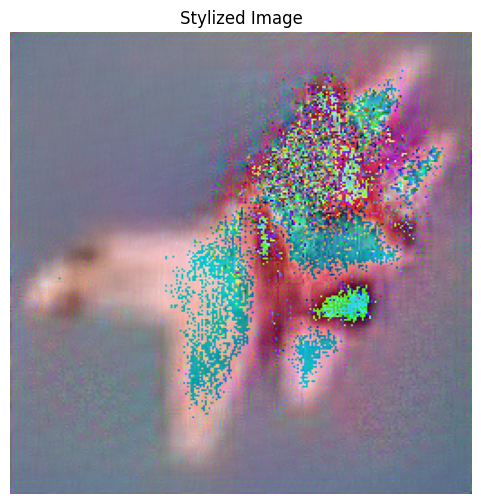

In [45]:
plt.figure(figsize=(6,6))
imshow(target, "Stylized Image")
plt.show()

In [46]:
# ;-; CIFAR WAS NOT MY CHOICE